# Paper Plot: Entropy Trajectories

This notebook creates a compact paper-ready plot for the Results discussion about exploration vs. exploitation. It uses the existing experiment outputs in `train/runs/reinforce_is/comparison` and only plots the methods discussed in that paragraph: `standard`, `naive`, `is`, `snis`, and `ppo_clip`.

In [5]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Match the color scheme used in train/reinforce_is.py
COLORS = {
    "standard":  "#1f77b4",
    "naive":     "#e377c2",
    "is":        "#2ca02c",
    "snis":      "#ff7f0e",
    "ppo_clip":  "#9467bd",
}

LABELS = {
    "standard": "Standard",
    "naive": "Naive",
    "is": "IS",
    "snis": "SNIS",
    "ppo_clip": "PPO clip",
}

METHODS = ["standard", "naive", "is", "snis", "ppo_clip"]
ENVS = ["CartPole-v1", "FrozenLake-v1", "Acrobot-v1", "LunarLander-v3", "HalfCheetah-v5"]

BASE_DIR = Path("train/runs/reinforce_is/comparison")
OUT_DIR = Path("paper_figures")
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [6]:
def load_metric(env, method, key="entropy"):
    """Load timesteps and one metric for a method/environment pair."""
    metrics_path = BASE_DIR / env
    matches = sorted(metrics_path.rglob(f"{method}/metrics.npz"))
    if not matches:
        raise FileNotFoundError(f"No metrics found for {env}/{method}")
    data = np.load(matches[-1], allow_pickle=True)
    return data["timestep"], data[key]


def smooth(y, window=5):
    """Centered moving average with edge padding; set window=1 for raw curves."""
    if window <= 1:
        return y
    pad_left = window // 2
    pad_right = window - 1 - pad_left
    padded = np.pad(y, (pad_left, pad_right), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(padded, kernel, mode="valid")

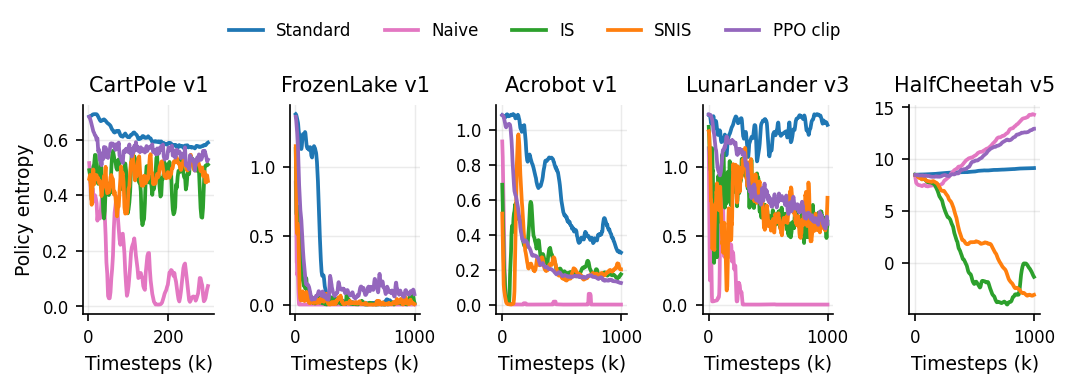

Saved paper_figures\entropy_trajectories_selected_methods.png
Saved paper_figures\entropy_trajectories_selected_methods.pdf


In [ ]:
# Entropy trajectory figure for the paper.
# Each subplot is one environment; lines show policy entropy over training.

fig, axes = plt.subplots(1, 5, figsize=(9.2, 2.35), sharey=False)

for ax, env in zip(axes, ENVS):
    for method in METHODS:
        timesteps, entropy = load_metric(env, method, key="entropy")
        ax.plot(
            timesteps / 1_000,
            smooth(entropy, window=5),
            color=COLORS[method],
            linewidth=1.8,
            label=LABELS[method],
        )

    ax.set_title(env.replace("-v", " v"))
    ax.set_xlabel("Timesteps (k)")
    ax.grid(True, alpha=0.25, linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Policy entropy")

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=len(METHODS),
    frameon=False,
)

fig.tight_layout(rect=(0, 0, 1, 0.96))

png_path = OUT_DIR / "entropy_trajectories_selected_methods.png"
pdf_path = OUT_DIR / "entropy_trajectories_selected_methods.pdf"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved {png_path}")
print(f"Saved {pdf_path}")

## SNIS vs. PPO Clip: Entropy and Reward

This figure compares the two strongest corrected reuse methods. Solid lines show policy entropy on the left axis; dashed lines show evaluation reward on the right axis.

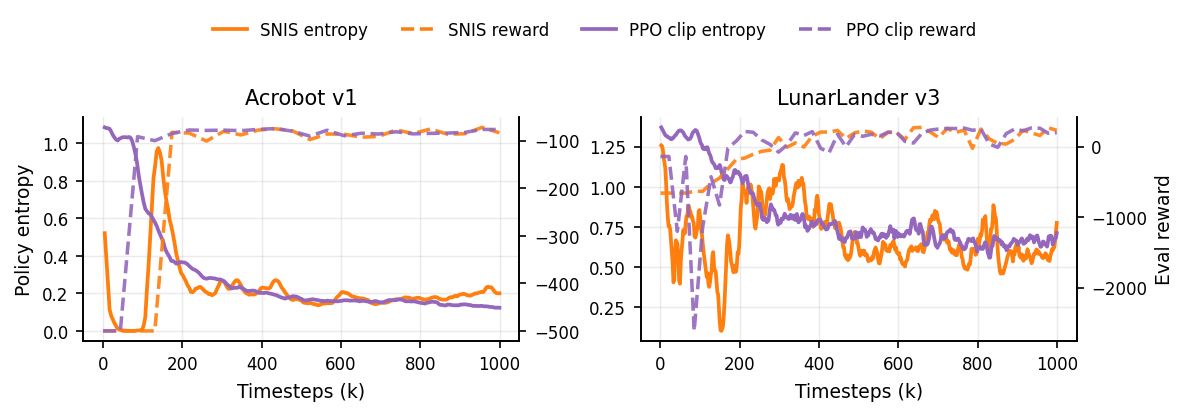

Saved paper_figures\snis_vs_ppo_entropy_reward.png
Saved paper_figures\snis_vs_ppo_entropy_reward.pdf


In [10]:
# Dual-axis plot for SNIS and PPO clipping.
# Solid lines: entropy, left axis. Dashed lines: eval reward, right axis.

FOCUS_METHODS = ["snis", "ppo_clip"]
FOCUS_ENVS = ["Acrobot-v1", "LunarLander-v3"]

fig, axes = plt.subplots(1, 2, figsize=(8, 2.45), sharey=False)

for ax_entropy, env in zip(axes, FOCUS_ENVS):
    ax_reward = ax_entropy.twinx()

    for method in FOCUS_METHODS:
        color = COLORS[method]

        ts_entropy, entropy = load_metric(env, method, key="entropy")
        ax_entropy.plot(
            ts_entropy / 1_000,
            smooth(entropy, window=5),
            color=color,
            linewidth=1.8,
            linestyle="-",
            label=f"{LABELS[method]} entropy",
        )

        metrics_path = sorted((BASE_DIR / env).rglob(f"{method}/metrics.npz"))[-1]
        data = np.load(metrics_path, allow_pickle=True)
        eval_reward = data["eval_mean"]
        eval_ts = np.linspace(0, data["timestep"][-1], len(eval_reward))
        ax_reward.plot(
            eval_ts / 1_000,
            eval_reward,
            color=color,
            linewidth=1.7,
            linestyle="--",
            alpha=0.9,
            label=f"{LABELS[method]} reward",
        )

    ax_entropy.set_title(env.replace("-v", " v"))
    ax_entropy.set_xlabel("Timesteps (k)")
    ax_entropy.grid(True, alpha=0.25, linewidth=0.7)
    ax_entropy.spines["top"].set_visible(False)
    ax_reward.spines["top"].set_visible(False)

    if ax_entropy is axes[0]:
        ax_entropy.set_ylabel("Policy entropy")
    if ax_entropy is axes[-1]:
        ax_reward.set_ylabel("Eval reward")

legend_handles = [
    plt.Line2D([0], [0], color=COLORS["snis"], lw=1.8, linestyle="-", label="SNIS entropy"),
    plt.Line2D([0], [0], color=COLORS["snis"], lw=1.7, linestyle="--", label="SNIS reward"),
    plt.Line2D([0], [0], color=COLORS["ppo_clip"], lw=1.8, linestyle="-", label="PPO clip entropy"),
    plt.Line2D([0], [0], color=COLORS["ppo_clip"], lw=1.7, linestyle="--", label="PPO clip reward"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    ncol=4,
    frameon=False,
)

fig.tight_layout(rect=(0, 0, 1, 0.96))

png_path = OUT_DIR / "snis_vs_ppo_entropy_reward.png"
pdf_path = OUT_DIR / "snis_vs_ppo_entropy_reward.pdf"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved {png_path}")
print(f"Saved {pdf_path}")